In [1]:
# Library
import pandas as pd
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.linear_model import LinearRegression
import xgboost as xgb

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error, r2_score

# Data Collection

In [2]:
df_gold = pd.read_csv("../data/raw/gold.csv")
df_idr = pd.read_csv("../data/raw/idr.csv")
df_oil = pd.read_csv("../data/raw/oil.csv")
df_dxy = pd.read_csv("../data/raw/dxy.csv")

### data ratio

In [3]:
print("Range of data (gold):")
print(df_gold.head().values[0])
print(df_gold.tail().values[0])
print("Range of data (idr):")
print(df_idr.head().values[0])
print(df_idr.tail().values[0])
print("Range of data (oil):")
print(df_oil.head().values[0])
print(df_oil.tail().values[0])
print("Range of data (dxy):")
print(df_dxy.head().values[0])
print(df_dxy.tail().values[0])

Range of data (gold):
['2000-08-30' 273.8999938964844 273.8999938964844 273.8999938964844
 273.8999938964844 0]
['2026-05-04' 4519.5 4581.2001953125 4512.7001953125 4581.2001953125 20]
Range of data (idr):
['2001-06-28' 11448.0 11565.0 11338.0 11441.0 0]
['2026-05-04' 17288.5 17415.0 17306.80078125 17327.0 0]
Range of data (oil):
['2000-08-23' 32.04999923706055 32.79999923706055 31.950000762939453
 31.950000762939453 79385]
['2026-05-04' 106.41999816894533 107.45999908447266 99.11000061035156
 99.7300033569336 342843]
Range of data (dxy):
['1971-01-04' 120.52999877929688 120.52999877929688 120.52999877929688
 120.52999877929688 0]
['2026-05-04' 98.47000122070312 98.54000091552734 97.97000122070312
 98.0500030517578 0]


# Preprocessing data

### Merge & clean data

In [4]:
df_daily = df_gold.merge(
    df_idr,
    on="Date",
    how="inner"
)

df_daily = df_daily.merge(
    df_oil,
    on="Date",
    how="inner"
)

df_daily = df_daily.merge(
    df_dxy,
    on="Date",
    how="inner"
)

In [5]:
df_daily["Date"] = pd.to_datetime(df_daily["Date"])
df_daily.info()
df_daily.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6039 entries, 0 to 6038
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         6039 non-null   datetime64[ns]
 1   gold_close   6039 non-null   float64       
 2   gold_high    6039 non-null   float64       
 3   gold_low     6039 non-null   float64       
 4   gold_open    6039 non-null   float64       
 5   gold_volume  6039 non-null   int64         
 6   idr_close    6039 non-null   float64       
 7   idr_high     6039 non-null   float64       
 8   idr_low      6039 non-null   float64       
 9   idr_open     6039 non-null   float64       
 10  idr_volume   6039 non-null   int64         
 11  oil_close    6039 non-null   float64       
 12  oil_high     6039 non-null   float64       
 13  oil_low      6039 non-null   float64       
 14  oil_open     6039 non-null   float64       
 15  oil_volume   6039 non-null   int64         
 16  dxy_cl

,Date,gold_close,gold_high,gold_low,gold_open,gold_volume,idr_close,idr_high,idr_low,idr_open,...,oil_close,oil_high,oil_low,oil_open,oil_volume,dxy_close,dxy_high,dxy_low,dxy_open,dxy_volume
count,6039,6039.000000,6039.000000,6039.000000,6039.000000,6039.000000,6039.000000,6039.000000,6039.000000,6039.000000,...,6039.000000,6039.000000,6039.000000,6039.000000,6.039000e+03,6039.000000,6039.000000,6039.000000,6039.000000,6.039000e+03
mean,2014-04-01 18:54:18.420268288,1362.918495,1370.333682,1355.209770,1362.918547,4455.836397,11962.656201,12058.944760,11862.914736,11952.916365,...,66.884178,67.945837,65.768250,66.894122,3.183486e+05,91.762641,92.089043,91.439230,91.756905,3.856599e+03
min,2001-06-28 00:00:00,264.600006,265.100006,263.700012,264.799988,0.000000,888.109985,9.000000,4.000000,9.000000,...,-37.630001,13.690000,-40.320000,-14.000000,0.000000e+00,71.330002,71.690002,70.699997,71.330002,0.000000e+00
25%,2008-03-27 12:00:00,835.050018,842.549988,826.299988,832.100006,28.000000,9240.000000,9301.550293,9160.000000,9242.250000,...,49.619999,50.470001,48.799999,49.610001,1.596380e+05,82.320000,82.599998,82.014999,82.285000,0.000000e+00
50%,2014-04-29 00:00:00,1276.400024,1282.300049,1272.900024,1278.000000,131.000000,11838.000000,11935.000000,11750.000000,11828.000000,...,66.080002,66.919998,65.000000,66.010002,2.869260e+05,92.370003,92.660004,92.129997,92.360001,0.000000e+00
75%,2020-05-05 12:00:00,1729.250000,1738.650024,1720.849976,1730.549988,483.500000,14321.399902,14368.000000,14243.828125,14333.000000,...,83.480000,84.704998,82.099998,83.490002,4.052670e+05,98.959999,99.260002,98.650002,98.940002,0.000000e+00
max,2026-05-08 00:00:00,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000,17389.800781,197804.000000,17353.000000,17389.800781,...,145.289993,147.270004,143.220001,145.190002,2.288230e+06,120.900002,121.019997,119.860001,120.760002,1.429000e+07
std,NaN,822.145480,828.600952,815.523950,822.301820,24677.031849,2693.276377,3605.625880,2753.591700,2742.622566,...,23.535908,23.783482,23.240616,23.523361,2.053394e+05,10.562099,10.581382,10.543684,10.566976,2.173016e+05


In [6]:
df_daily.isnull().sum()

Date           0
gold_close     0
gold_high      0
gold_low       0
gold_open      0
gold_volume    0
idr_close      0
idr_high       0
idr_low        0
idr_open       0
idr_volume     0
oil_close      0
oil_high       0
oil_low        0
oil_open       0
oil_volume     0
dxy_close      0
dxy_high       0
dxy_low        0
dxy_open       0
dxy_volume     0
dtype: int64

In [7]:
df_daily.duplicated().sum()

np.int64(0)

# EDA

## Correlation Analysis

Text(0.5, 1.0, 'Correlation Heatmap')

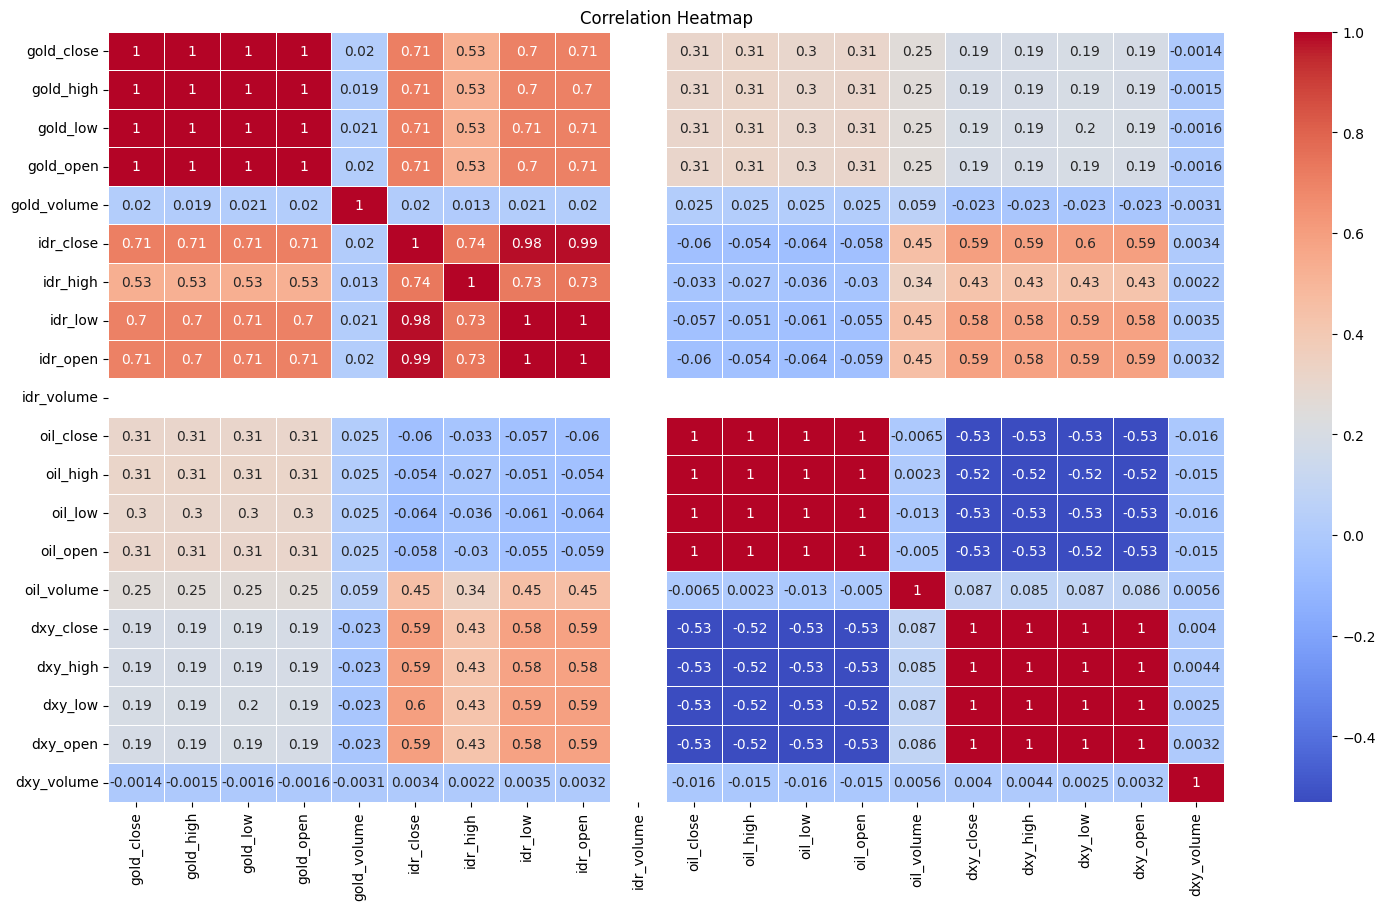

In [8]:
df_daily.corr(numeric_only=True)

plt.figure(figsize=(18, 10))
sns.heatmap(df_daily.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")

## Trend Analysis

In [9]:
df_plot = df_daily.copy()

cols = ["gold_close", "oil_close", "dxy_close", "idr_close"]

for col in cols:
    df_plot[col] = (
        df_plot[col] / df_plot[col].iloc[0]
    ) * 100

px.line(
    df_plot,
    x="Date",
    y=cols,
    title="Normalized Market Trends"
)

## Gold moving avarage

Text(0.5, 1.0, 'Gold Price with 30-Day Moving Average')

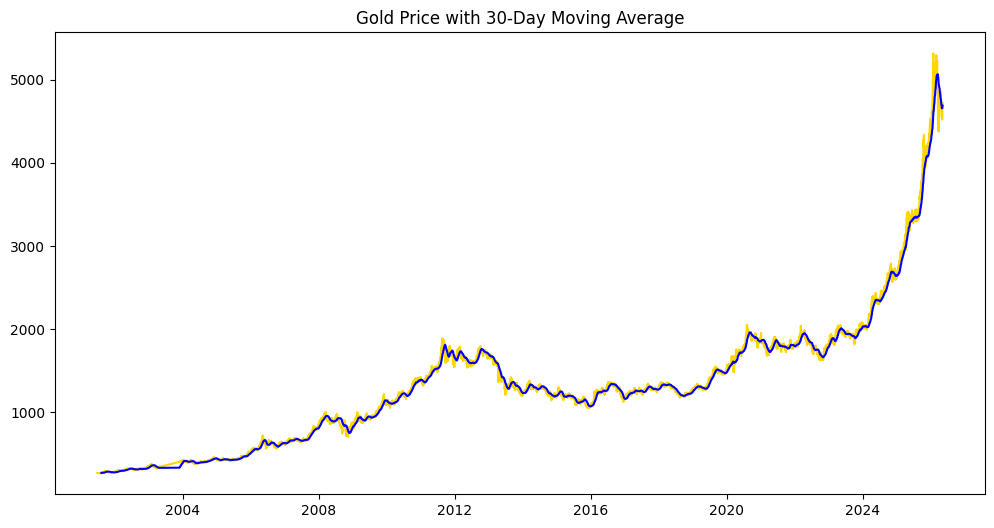

In [10]:
df_daily["gold_close"].rolling(30).mean()
plt.figure(figsize=(12, 6))
plt.plot(df_daily["Date"], df_daily["gold_close"], label="Gold Price", color="gold")
plt.plot(df_daily["Date"], df_daily["gold_close"].rolling(30).mean(), label="30-Day Moving Average", color="blue")
plt.title("Gold Price with 30-Day Moving Average")  

# Feature Engineering

In [11]:
# Lag Features
df_daily["gold_close_lag1"] = df_daily["gold_close"].shift(1)
df_daily["gold_close_lag7"] = df_daily["gold_close"].shift(7)
df_daily["gold_close_lag30"] = df_daily["gold_close"].shift(30)  

# Rolling Mean
df_daily["gold_close_roll_mean_7"] = df_daily["gold_close"].rolling(window=7).mean()
df_daily["gold_close_roll_mean_30"] = df_daily["gold_close"].rolling(window=30).mean()

# Rolling Std
df_daily["gold_close_roll_std_7"] = df_daily["gold_close"].rolling(window=7).std()
df_daily["gold_close_roll_std_30"] = df_daily["gold_close"].rolling(window=30).std()    

In [12]:
df_daily = df_daily.dropna()

df_daily.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6009 entries, 30 to 6038
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     6009 non-null   datetime64[ns]
 1   gold_close               6009 non-null   float64       
 2   gold_high                6009 non-null   float64       
 3   gold_low                 6009 non-null   float64       
 4   gold_open                6009 non-null   float64       
 5   gold_volume              6009 non-null   int64         
 6   idr_close                6009 non-null   float64       
 7   idr_high                 6009 non-null   float64       
 8   idr_low                  6009 non-null   float64       
 9   idr_open                 6009 non-null   float64       
 10  idr_volume               6009 non-null   int64         
 11  oil_close                6009 non-null   float64       
 12  oil_high                 6009 non-null

# Split train test

In [13]:
# sort by date
df_final = df_daily.sort_values('Date')

# Set 'Date' as the index for time series analysis
df_final = df_final.set_index('Date')

# fitur target
df_final["target"] = df_final["gold_close"].shift(-1)
df_final = df_final.dropna()

# variabel X dan y
X = df_final.drop(columns=['gold_close', 'gold_high', 'gold_low', 'gold_open', 'target'])
y = df_final['target']

# split
test_size = 0.2
split_index = int(len(df_final) * (1 - test_size))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4806, 23)
(1202, 23)
(4806,)
(1202,)


## Scaling

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeling

## Baseline model (linear regression)

In [16]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 31.576476078975052
RMSE: 54.75698841356969
R2  : 0.9965174305846841


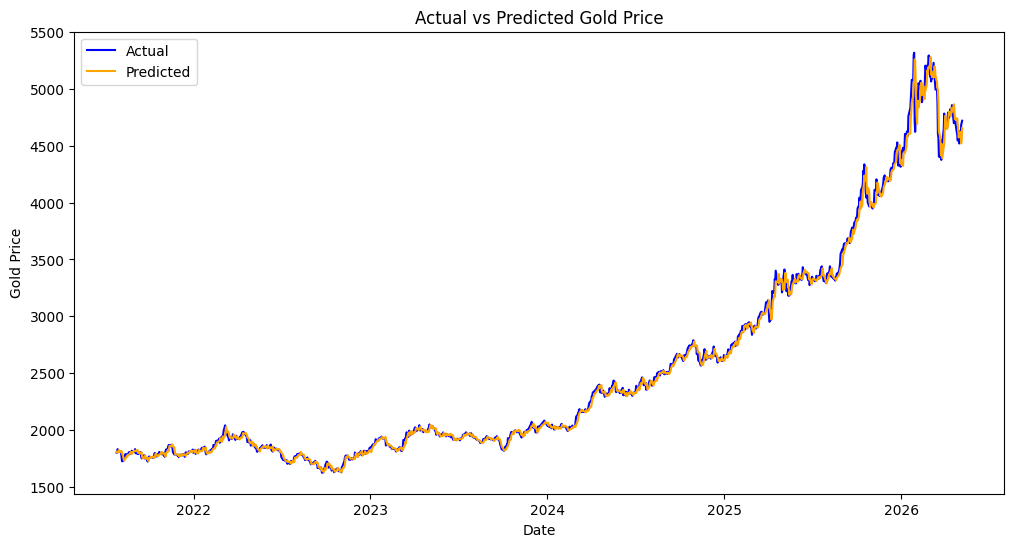

In [17]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Actual", color="blue")
plt.plot(y_test.index, y_pred, label="Predicted", color="orange")
plt.title("Actual vs Predicted Gold Price")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()

## Compare model (XBoost)

In [18]:
xgb_model = xgb.XGBRegressor(    
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse',
    )

# training
xgb_model.fit(X_train, y_train)

# prediksi
y_pred_xgb = xgb_model.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Evaluation")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

XGBoost Evaluation
MAE : 647.1623088309848
RMSE: 1103.5726672751182
R2  : -0.41456381384281316


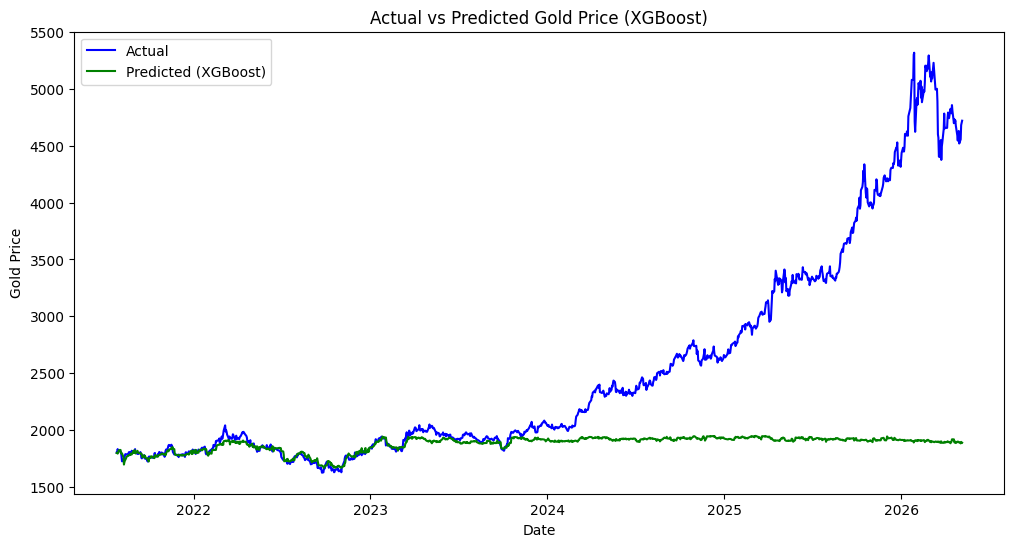

In [20]:
# Plot actual vs predicted for XGBoost
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Actual", color="blue")
plt.plot(y_test.index, y_pred_xgb, label="Predicted (XGBoost)", color="green")
plt.title("Actual vs Predicted Gold Price (XGBoost)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()

### Add feature time-aware for XGBoost

In [21]:
df_final["year"] = df_final.index.year
df_final["month"] = df_final.index.month
df_final["day"] = df_final.index.day
df_final["time_idx"] = range(len(df_final))

In [22]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6008 entries, 2001-08-14 to 2026-05-07
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gold_close               6008 non-null   float64
 1   gold_high                6008 non-null   float64
 2   gold_low                 6008 non-null   float64
 3   gold_open                6008 non-null   float64
 4   gold_volume              6008 non-null   int64  
 5   idr_close                6008 non-null   float64
 6   idr_high                 6008 non-null   float64
 7   idr_low                  6008 non-null   float64
 8   idr_open                 6008 non-null   float64
 9   idr_volume               6008 non-null   int64  
 10  oil_close                6008 non-null   float64
 11  oil_high                 6008 non-null   float64
 12  oil_low                  6008 non-null   float64
 13  oil_open                 6008 non-null   float64
 14  oil_vo

In [23]:
# fitur target
df_final["target"] = df_final["gold_close"].shift(-1)
df_final = df_final.dropna()

# variabel X dan y
X_xgb = df_final.drop(columns=['gold_close', 'gold_high', 'gold_low', 'gold_open', 'target'])
y_xgb = df_final['target']

# split
test_size = 0.2
split_index = int(len(df_final) * (1 - test_size))

X_train_xgb = X_xgb.iloc[:split_index]
X_test_xgb = X_xgb.iloc[split_index:]
y_train_xgb = y_xgb.iloc[:split_index]
y_test_xgb = y_xgb.iloc[split_index:]

print(X_train_xgb.shape)
print(X_test_xgb.shape)
print(y_train_xgb.shape)
print(y_test_xgb.shape)

(4805, 27)
(1202, 27)
(4805,)
(1202,)


### Retrain for improvement

In [24]:
xgb_model = xgb.XGBRegressor(    
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse',
    )

# training
xgb_model.fit(X_train_xgb, y_train_xgb)

# prediksi
y_pred_xgb = xgb_model.predict(X_test_xgb)

In [25]:
mae = mean_absolute_error(y_test_xgb, y_pred_xgb)
mse = mean_squared_error(y_test_xgb, y_pred_xgb)
rmse = mse ** 0.5
r2 = r2_score(y_test_xgb, y_pred_xgb)

print("XGBoost Evaluation with Date Features")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

XGBoost Evaluation with Date Features
MAE : 650.6412767864107
RMSE: 1099.346807390229
R2  : -0.4096798888910864


### Changing feature target from raw price to daily return

In [26]:
df_final_xgb = df_final.copy()

df_final_xgb["gold_return"] = (
    df_final_xgb["gold_close"].pct_change()
)

df_final_xgb["target_return"] = (
    df_final_xgb["gold_return"].shift(-1)
)

df_final_xgb["oil_return"] = (
    df_final_xgb["oil_close"].pct_change()
)

df_final_xgb["dxy_return"] = (
    df_final_xgb["dxy_close"].pct_change()
)

df_final_xgb["idr_return"] = (
    df_final_xgb["idr_close"].pct_change() 
)

df_final_xgb["gold_return_lag1"] = df_final_xgb["gold_return"].shift(1)
df_final_xgb["gold_return_lag7"] = df_final_xgb["gold_return"].shift(7)

df_final_xgb = df_final_xgb.drop(columns=['gold_return', 'gold_high', 'gold_low', 'gold_open', 'gold_close', 'target',
                                          'oil_close', 'dxy_close', 'idr_close','oil_open', 'dxy_open', 'idr_open', 
                                          'oil_high', 'oil_low', 'dxy_high', 'dxy_low', 'idr_high', 'idr_low',
                                          'gold_close_lag1', 'gold_close_lag7', 'gold_close_lag30', 'gold_close_roll_mean_7', 
                                          'gold_close_roll_mean_30', 'gold_close_roll_std_7', 'gold_close_roll_std_30'])

df_final_xgb = df_final_xgb.dropna()

In [27]:
df_final_xgb.columns.tolist()

['gold_volume',
 'idr_volume',
 'oil_volume',
 'dxy_volume',
 'year',
 'month',
 'day',
 'time_idx',
 'target_return',
 'oil_return',
 'dxy_return',
 'idr_return',
 'gold_return_lag1',
 'gold_return_lag7']

In [28]:
# variabel X dan y
X_xgb = df_final_xgb.drop(columns=['target_return'])
y_xgb = df_final_xgb['target_return']

# split
test_size = 0.2
split_index = int(len(df_final_xgb) * (1 - test_size))

X_train_xgb = X_xgb.iloc[:split_index]
X_test_xgb = X_xgb.iloc[split_index:]
y_train_xgb = y_xgb.iloc[:split_index]
y_test_xgb = y_xgb.iloc[split_index:]

print(X_train_xgb.shape)
print(X_test_xgb.shape)
print(y_train_xgb.shape)
print(y_test_xgb.shape)

(4798, 13)
(1200, 13)
(4798,)
(1200,)


In [29]:
xgb_model = xgb.XGBRegressor(    
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse',
    )

# training
xgb_model.fit(X_train_xgb, y_train_xgb)

# prediksi
y_pred_xgb = xgb_model.predict(X_test_xgb)

In [30]:
mae = mean_absolute_error(y_test_xgb, y_pred_xgb)
mse = mean_squared_error(y_test_xgb, y_pred_xgb)
rmse = mse ** 0.5
r2 = r2_score(y_test_xgb, y_pred_xgb)

print("XGBoost Evaluation with return features")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

XGBoost Evaluation with return features
MAE : 0.008536698189522341
RMSE: 0.011865680539153663
R2  : -0.05181475311469752


### retrain again with diff feature engineering

In [31]:
# Volatility Features
df_final_xgb["gold_return_volatility_7"] = (
    df_final_xgb["gold_return_lag1"]
    .rolling(7)
    .std()
)

df_final_xgb["gold_return_volatility_30"] = (
    df_final_xgb["gold_return_lag1"]
    .rolling(30)
    .std()
)

# Momentum Features
df_final_xgb["gold_return_momentum_7"] = (
    df_final_xgb["gold_return_lag1"]
    .rolling(7)
    .mean()
)

In [32]:
# variabel X dan y
X_xgb = df_final_xgb.drop(columns=['target_return'])
y_xgb = df_final_xgb['target_return']

# split
test_size = 0.2
split_index = int(len(df_final_xgb) * (1 - test_size))

X_train_xgb = X_xgb.iloc[:split_index]
X_test_xgb = X_xgb.iloc[split_index:]
y_train_xgb = y_xgb.iloc[:split_index]
y_test_xgb = y_xgb.iloc[split_index:]

print(X_train_xgb.shape)
print(X_test_xgb.shape)
print(y_train_xgb.shape)
print(y_test_xgb.shape)

(4798, 16)
(1200, 16)
(4798,)
(1200,)


In [33]:
xgb_model = xgb.XGBRegressor(    
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse',
    )

# training
xgb_model.fit(X_train_xgb, y_train_xgb)

# prediksi
y_pred_xgb = xgb_model.predict(X_test_xgb)

In [34]:
mae = mean_absolute_error(y_test_xgb, y_pred_xgb)
mse = mean_squared_error(y_test_xgb, y_pred_xgb)
rmse = mse ** 0.5
r2 = r2_score(y_test_xgb, y_pred_xgb)

print("XGBoost Evaluation with return features + volatility/momentum features")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

XGBoost Evaluation with return features + volatility/momentum features
MAE : 0.008402408005315385
RMSE: 0.011845704438587257
R2  : -0.04827623362174194


C:\Users\Haikal Firdaus\AppData\Local\Temp\ipykernel_5440\1113575845.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


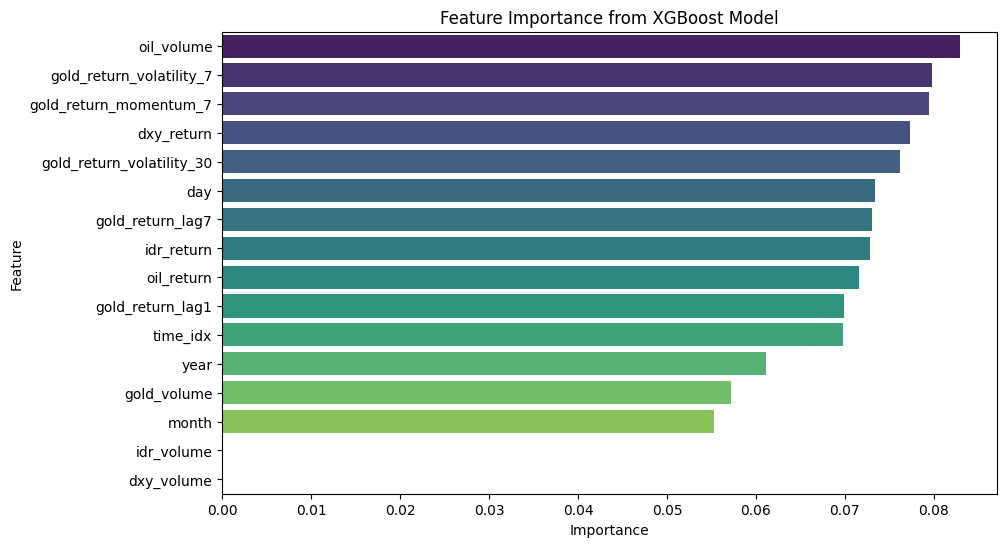

In [36]:
importances = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_xgb.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance from XGBoost Model')
plt.show()

## Compare model (LSTM)